<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
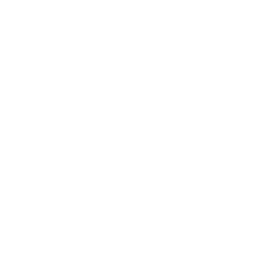
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Diagnose der Chemiereaktor-Störung</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Identifikation der Variablen, die die T²-Überschreitung des Reaktors während der Störung verursachen &nbsp;|&nbsp; März 2026</p>
</div>
</div>
</div>

## Zusammenfassung

Ein kontinuierlich gerührter Rührkesselreaktor (CSTR, Continuous
Stirred-Tank Reactor) geriet in eine thermische Störung, als seine
Kühlmittelversorgung ausfiel. Im Normalbetrieb bewegen sich
Kühlmittelfluss, Reaktortemperatur und Manteltemperatur gemeinsam
entlang einer einzigen Prozesslast-Achse. Wir trainieren ein
Drei-Komponenten-MVP-Modell auf 100 Beobachtungen im Normalbetrieb und
bewerten anschließend 100 Störungsbeobachtungen mit `PROC MVPDIAGNOSE`
dagegen. Die Zerlegung von Hotellings *T*-Quadrat-Statistik in Beiträge
je Variable isoliert das thermisch gekoppelte Trio — `jacket_temp`,
`coolant_flow` und `reactor_temp` — als die Variablen, die die
Überschreitung verursachen, und weist den Betrieb direkt auf das
Kühlmittelsubsystem hin.


## Datenquellen

| Datensatz | Rolle | Beobachtungen |
|---|---|---|
| `reactor_normal` | Trainingsdaten des Normalbetriebs für das MVP-Modell | 100 |
| `reactor_upset` | Störungsbeobachtungen, die gegen das Modell bewertet werden | 100 |

Die fünf gemessenen Variablen sind `reactor_temp` (C), `coolant_flow`
(L/min), `jacket_temp` (C), `feed_conc` (g/L) und `pressure` (bar).
Beide Datensätze werden aus einer gemeinsamen latenten *Prozesslast*
simuliert, sodass die Normaldaten dieselbe Korrelationsstruktur wie ein
realer CSTR aufweisen; die Störung fügt einen Kühlmittelausfall ein,
der diese Struktur aufbricht.


## Schritt 1 — Trainieren des MVP-Modells für den Normalbetrieb

Der Normalbetrieb wird durch eine latente Prozesslast bestimmt: eine
höhere Last senkt den Kühlmittelfluss, während sie Reaktor- und
Manteltemperatur ansteigen lässt. `PROC MVPMODEL` extrahiert drei
Hauptkomponenten aus den 100 Beobachtungen des Normalbetriebs und
speichert sie mit `OUTMODEL=`, damit der Diagnoseschritt neue Daten
gegen dieselbe Referenz bewerten kann.


In [1]:
DATEN reactor_normal;
  AUFRUFEN streaminit(7);
  AUSFÜHRUNG t = 1 BIS 100;
    load = rand('normal', 0, 1);                 /* latente Prozesslast */
    reactor_temp = 85.0 + 2.5*load + rand('normal', 0, 0.5);
    coolant_flow = 45.0 - 3.0*load + rand('normal', 0, 0.6);
    jacket_temp  = 22.0 + 1.8*load + rand('normal', 0, 0.4);
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*load + rand('normal', 0, 0.05);
    AUSGABE;
  ENDE;
AUSFÜHREN;

PROZEDUR mvpmodel DATEN=reactor_normal outmodel=reactor_model;
  VAR reactor_temp coolant_flow jacket_temp feed_conc pressure;
  ncomp=3;
AUSFÜHREN;



                    The MVPMODEL Procedure

  Data Set:          reactor_normal
  Number of Variables: 5
  Missing Value Handling: Exclude
  Number of Observations Read: 100
  Number of Observations Used: 100
  Number of Principal Components: 3

  Correlation Matrix
         reactor_tempcoolant_flowjacket_temp feed_conc  pressure
  reactor_temp    1.0000   -0.9611    0.9530   -0.0726    0.9662
  coolant_flow   -0.9611    1.0000   -0.9636    0.0281   -0.9712
  jacket_temp    0.9530   -0.9636    1.0000    0.0008    0.9720
  feed_conc   -0.0726    0.0281    0.0008    1.0000   -0.0326
  pressure    0.9662   -0.9712    0.9720   -0.0326    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 3.89511286  2.89376076    0.7790    0.7790
    2 1.00135210  0.95664889    0.2003    0.9793
    3 0.04470321                0.0089    0.9882




NOTE: DATA reactor_normal


NOTE: Wrote reactor_normal (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


## Schritt 2 — Bewertung des Störungsereignisses und Zerlegung von *T*-Quadrat

Die Störung senkt den Kühlmittelfluss um etwa 12 L/min, während
Reaktor- und Manteltemperatur ansteigen — die normale Kopplung
zwischen Kühlmittel und Temperatur ist aufgebrochen. `PROC MVPDIAGNOSE`
bewertet jede Störungsbeobachtung gegen das Referenzmodell und
schreibt die standardisierten Scores und Residuen nach `OUT=` sowie die
Beiträge je Variable zu *T*-Quadrat nach `OUTCONTRIB=`. Jede
Beobachtung liegt weit außerhalb der Kontrollgrenze, was eine
anhaltende multivariate Abweichung statt isoliertes Rauschen bestätigt.


In [2]:
DATEN reactor_upset;
  AUFRUFEN streaminit(101);
  AUSFÜHRUNG t = 1 BIS 100;
    load = rand('normal', 0, 1);
    /* Kühlmittelpumpe fällt aus: Fluss sinkt, Temperaturen laufen davon */
    reactor_temp = 85.0 + 2.5*load + rand('normal', 0, 0.5) + 8.0;
    coolant_flow = 45.0 - 3.0*load + rand('normal', 0, 0.6) - 12.0;
    jacket_temp  = 22.0 + 1.8*load + rand('normal', 0, 0.4) + 5.0;
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*load + rand('normal', 0, 0.05);
    obs_time = t;
    AUSGABE;
  ENDE;
AUSFÜHREN;

PROZEDUR mvpdiagnose DATEN=reactor_upset MODELL=reactor_model
                 out=reactor_scores;
  VAR reactor_temp coolant_flow jacket_temp feed_conc pressure;
  id obs_time;
  outcontrib=reactor_contrib;
AUSFÜHREN;



                    The MVPDIAGNOSE Procedure

  Variables:           5
  Observations:        100
  T-squared limit:     14.8750
  Out-of-control:      100

  Out-of-control observations:
    Obs 1: T2 = 2090.8063
    Obs 2: T2 = 999.7924
    Obs 3: T2 = 1527.3324
    Obs 4: T2 = 2991.6777
    Obs 5: T2 = 3777.1420
    Obs 6: T2 = 1902.6525
    Obs 7: T2 = 3769.1715
    Obs 8: T2 = 2615.9714
    Obs 9: T2 = 1143.3295
    Obs 10: T2 = 3332.9549
    Obs 11: T2 = 2752.9890
    Obs 12: T2 = 2494.0743
    Obs 13: T2 = 3270.5544
    Obs 14: T2 = 5566.4499
    Obs 15: T2 = 3268.5867
    Obs 16: T2 = 3393.2374
    Obs 17: T2 = 1646.0731
    Obs 18: T2 = 2328.4410
    Obs 19: T2 = 1748.7747
    Obs 20: T2 = 3117.7899
    ... and 80 more





NOTE: DATA reactor_upset


NOTE: Wrote reactor_upset (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPDIAGNOSE
NOTE: PROC MVPDIAGNOSE statement used.


## Schritt 3 — Rangfolge der mittleren Beiträge

`OUTCONTRIB=` schreibt eine Zeile je bewerteter Beobachtung mit einer
`<variable>_CONTRIB`-Spalte für jede Prozessvariable. Die Mittelung
dieser Spalten liefert den mittleren Beitrag jeder Variablen zur
Störung; eine Transponierung formt die einzeilige Zusammenfassung in
eine übersichtliche Variable/Wert-Tabelle um, die die Störungstreiber
in eine Rangfolge bringt.


In [3]:
PROZEDUR MITTELWERTE DATEN=reactor_contrib mean NOPRINT;
  VAR reactor_temp_contrib coolant_flow_contrib jacket_temp_contrib
      feed_conc_contrib pressure_contrib;
  AUSGABE out=contrib_means
    mean=mc_reactor_temp mc_coolant_flow mc_jacket_temp
         mc_feed_conc mc_pressure;
AUSFÜHREN;

PROZEDUR TRANSPOSE DATEN=contrib_means out=contrib_long name=metric;
  VAR mc_reactor_temp mc_coolant_flow mc_jacket_temp
      mc_feed_conc mc_pressure;
AUSFÜHREN;

/* Ordnet lesbare Variablennamen und den mittleren Beitragswert zu */
DATEN contrib_ranked;
  FESTLEGEN contrib_long;
  LÄNGE variable $24;
  WENN      metric = 'mc_reactor_temp' DANN variable = 'Reaktortemperatur';
  SONST WENN metric = 'mc_coolant_flow' DANN variable = 'Kühlmittelfluss';
  SONST WENN metric = 'mc_jacket_temp'  DANN variable = 'Manteltemperatur';
  SONST WENN metric = 'mc_feed_conc'    DANN variable = 'Zulaufkonzentration';
  SONST WENN metric = 'mc_pressure'     DANN variable = 'Druck';
  mean_contrib = col1;
  BEHALTEN variable mean_contrib;
AUSFÜHREN;

PROZEDUR SORTIEREN DATEN=contrib_ranked;
  NACH ABSTEIGEND mean_contrib;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=contrib_ranked noobs BEZEICHNUNG;
  VAR variable mean_contrib;
  BEZEICHNUNG variable='Prozessvariable' mean_contrib='Mittlerer T²-Beitrag';
AUSFÜHREN;



    Prozessvariable   Mittlerer T²-Beitrag
-------------------  ---------------------
Manteltemperatur             4177.66720283
Kühlmittelfluss              2882.19501987
Reaktortemperatur            1602.04200377
Druck                         280.73140863
Zulaufkonzentration            61.43535437




NOTE: PROC MEANS
NOTE: Output dataset contrib_means has 1 observations and 7 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC TRANSPOSE data=contrib_means

NOTE: Created 5 rows.
NOTE: Output written to ./work/3a6033d7-98e4-4a92-bc43-39c382f86413/contrib_long.avro.
NOTE: DATA contrib_ranked


NOTE: Read 5 rows from contrib_long.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=contrib_ranked

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from contrib_ranked.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=contrib_ranked

NOTE: PROC PRINT completed: 5 observations printed, 2 variables


## Schritt 4 — Beitragsdiagramm

Das Beitragsdiagramm macht die Diagnose sofort sichtbar: Das thermisch
gekoppelte Trio — `jacket_temp`, `coolant_flow` und `reactor_temp` —
überragt `feed_conc` und `pressure`, die kaum ins Gewicht fallen. Die
drei dominanten Balken sind genau die Variablen, die durch den
Kühlkreislauf miteinander verbunden sind, sodass die Störung eindeutig
thermischer Natur ist und kein Zulauf- oder Druckproblem darstellt.



NOTE: PROC SGPLOT data=contrib_ranked

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


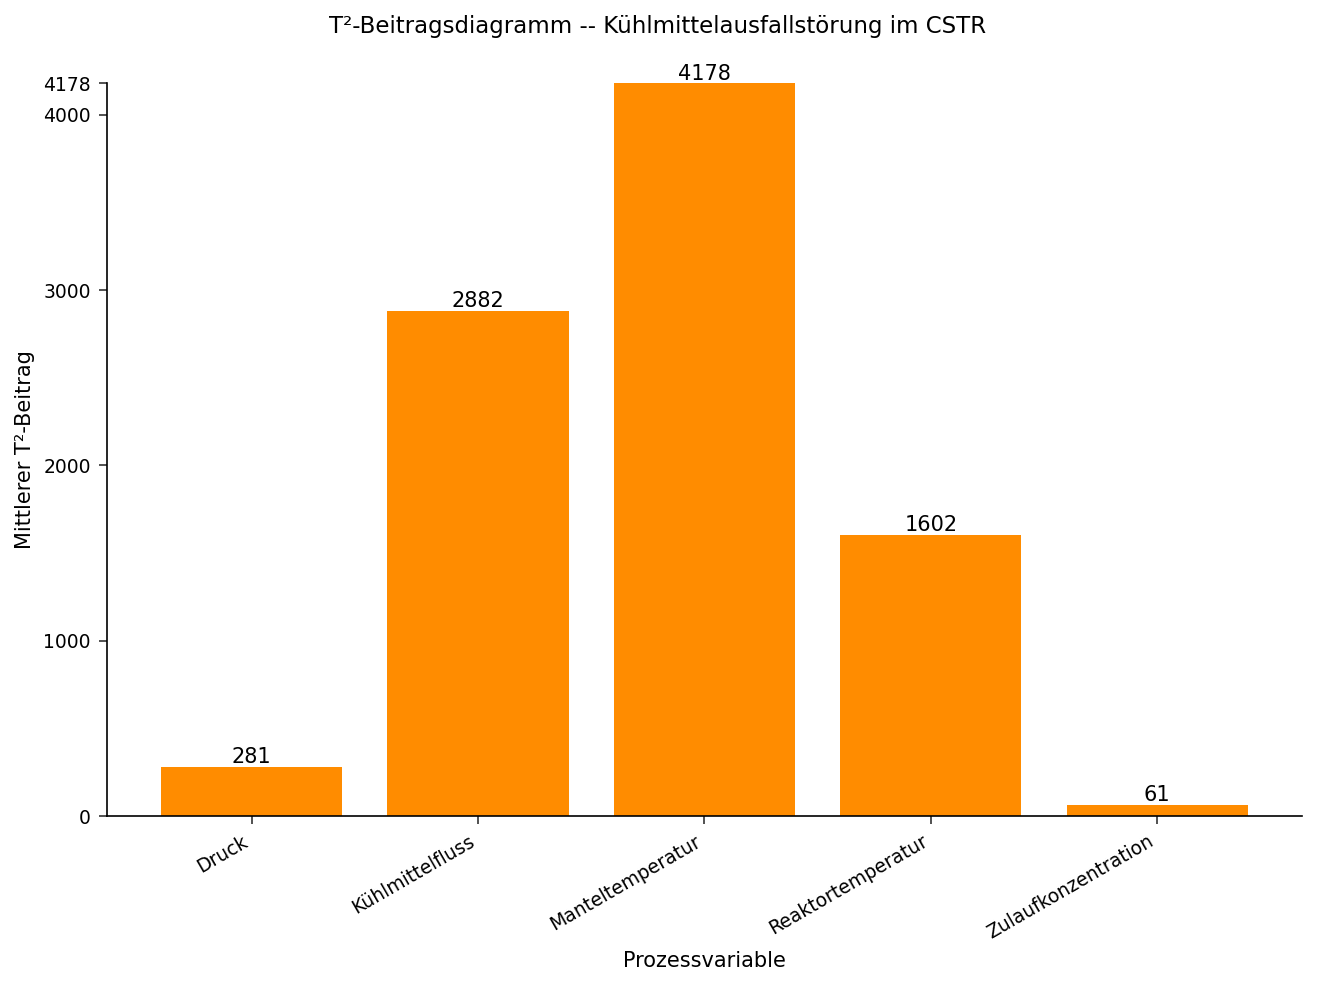

In [4]:
PROZEDUR SGPLOT DATEN=contrib_ranked;
  VBAR variable / RESPONSE=mean_contrib
                  fillattrs=(color=darkorange)
                  DATALABEL;
  XAXIS BEZEICHNUNG='Prozessvariable';
  YAXIS BEZEICHNUNG='Mittlerer T²-Beitrag';
  TITEL 'T²-Beitragsdiagramm -- Kühlmittelausfallstörung im CSTR';
AUSFÜHREN;


## Schritt 5 — Kontrollverlauf von *T*-Quadrat

Das Auftragen von *T*-Quadrat je Beobachtung gegen die Kontrollgrenze
des Modells zeigt, dass die Abweichung durchgängig ist: Jede
Störungsbeobachtung liegt um Größenordnungen über der Grenzlinie.
Innerhalb des Beobachtungsfensters findet keine Erholung statt, was zu
einem Hardwarefehler passt, der bestehen bleibt, bis das
Kühlmittelsubsystem gewartet wird.



NOTE: PROC SGPLOT data=reactor_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


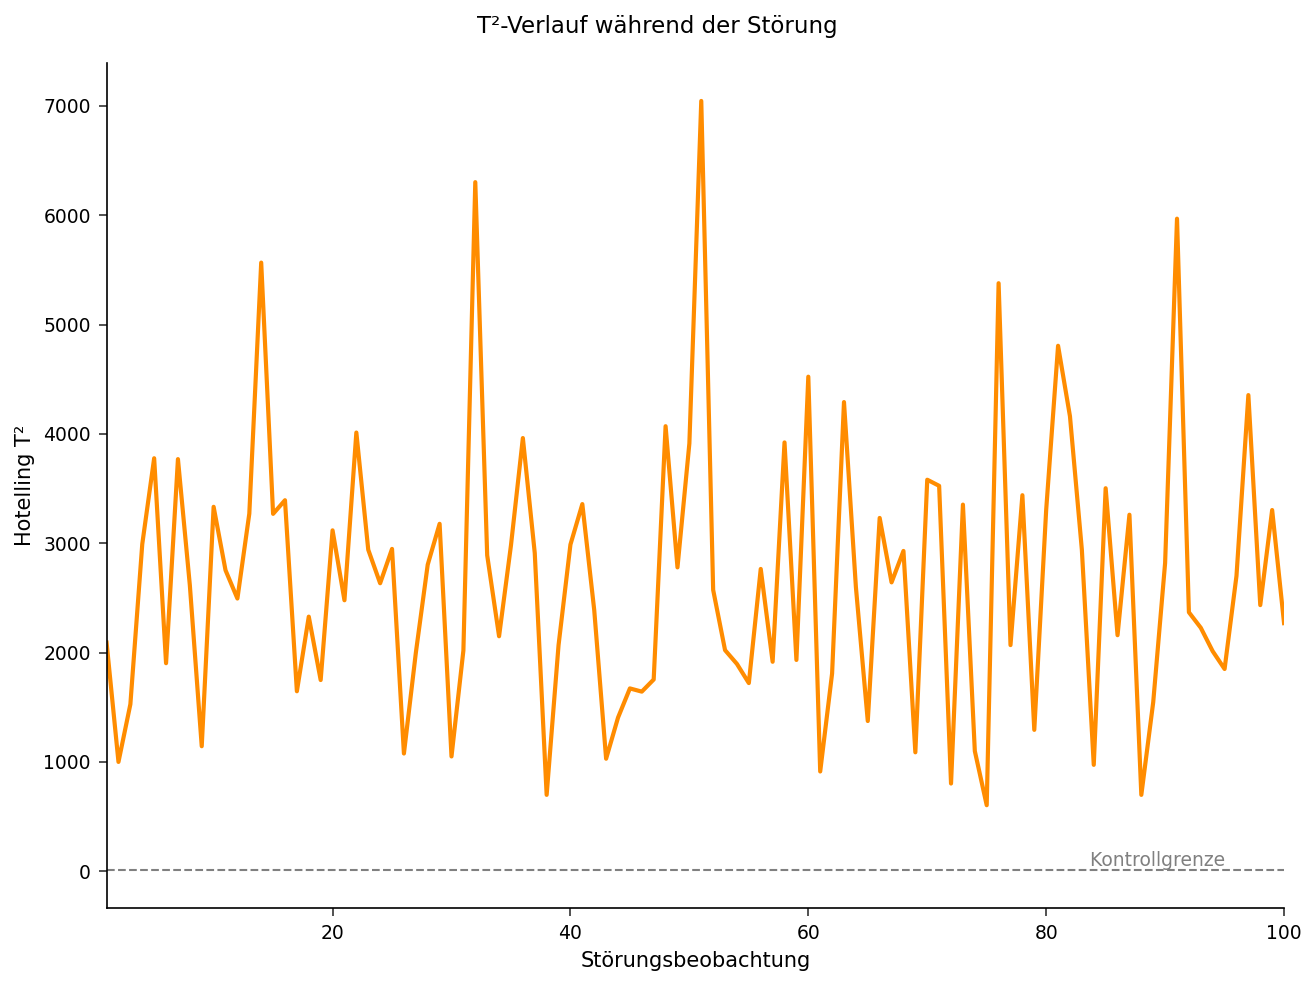

In [5]:
PROZEDUR SGPLOT DATEN=reactor_scores;
  SERIES x=_OBS y=_TSQUARED / LINEATTRS=(color=darkorange thickness=2);
  REFLINE 14.87 / AXIS=y
                  BEZEICHNUNG='Kontrollgrenze'
                  LINEATTRS=(pattern=dash color=gray);
  XAXIS BEZEICHNUNG='Störungsbeobachtung';
  YAXIS BEZEICHNUNG='Hotelling T²';
  TITEL 'T²-Verlauf während der Störung';
AUSFÜHREN;


## Befunde &amp; Korrekturmaßnahmen

- **Haupttreiber**: `jacket_temp`, `coolant_flow` und `reactor_temp`
  machen zusammen praktisch das gesamte *T*-Quadrat-Signal aus; ihre
  mittleren Beiträge liegen zwei bis drei Größenordnungen über
  `feed_conc` und `pressure`.
- **Grundursache**: ein Ausfall der Kühlmittelversorgung.
  `coolant_flow` ist die einzige *gesteuerte* Variable der drei — die
  Temperaturanstiege sind nachgelagerte Folgen des Kühlungsausfalls,
  sodass die behebbare Störung im Kühlmittelsubsystem liegt.
- **Kontrollstatus**: Alle 100 Störungsbeobachtungen überschreiten die
  *T*-Quadrat-Grenze, was auf eine anhaltende Abweichung statt eine
  vorübergehende Störung hindeutet.
- **Korrekturmaßnahme**: Kühlmittelpumpe prüfen und instand setzen;
  einen redundanten Kühlmittelfluss-Messumformer ergänzen, damit ein
  künftiger Versorgungsausfall durch univariate Alarmierung erkannt
  wird, bevor er sich auf den Temperaturkreislauf ausweitet.


## Export der gerankten Beiträge

Die gerankte Beitragstabelle wird für den Bericht nach dem Ereignis und
nachgelagerte Dashboards als CSV geschrieben.


In [6]:
PROZEDUR EXPORT DATEN=contrib_ranked
            OUTFILE='reactor_upset_contributions.csv'
            DBMS=csv REPLACE;
AUSFÜHREN;



NOTE: PROC EXPORT data=contrib_ranked outfile=reactor_upset_contributions.csv

NOTE: Exported 5 rows to reactor_upset_contributions.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertraulich
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Bereitgestellt von <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>